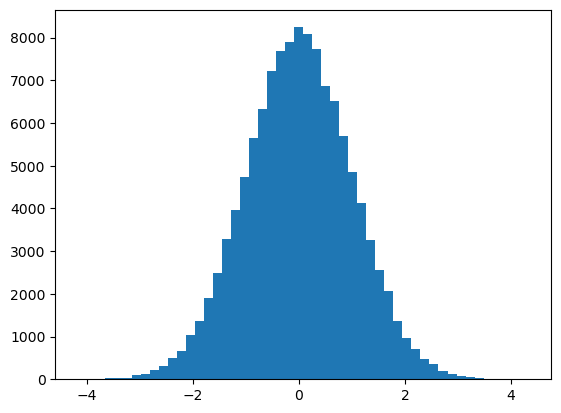

In [12]:
# demo of torch.randn
import torch
import matplotlib.pyplot as plt

randn = torch.randn(300, 400)
plt.hist(randn.flatten().numpy(), bins=50)
plt.show()

In [13]:
# demo of building a custom neural network using nn.Module
import torch.nn as nn

class MyFirstNN(nn.Module):
    """
    It inherits from nn.Module, which is PyTorch's base class for all neural networks.
    MyFirstNN gets all the built-in functionality of nn.Module (like tracking parameters, saving/loading, etc.)
    You're extending it with your own custom architecture
    """
    def __init__(self):
        super().__init__()
        """
        In OOP, composition = building a complex object using smaller objects.
        Each of these:
        nn.Linear(...)
        nn.ReLU()
        is already a fully functional object.
        So your class is basically assembling a system out of smaller objects.
        """
        self.fc1 = nn.Linear(10, 20)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(20, 1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    
model = MyFirstNN()
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters in MyFirstNN: {total_params}")

MyFirstNN(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)
Total parameters in MyFirstNN: 241


In [14]:
# training loop
# --- Data ---
X = torch.randn(100, 10)          # 100 samples, 10 features
y = torch.randn(100, 1)           # 100 target values

# --- Model, Loss, Optimizer ---
model = MyFirstNN()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# --- Training Loop ---
for epoch in range(100):
    # 1. Forward pass
    predictions = model(X)
    loss = criterion(predictions, y)

    # 2. Backward pass
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute new gradients

    # 3. Update weights
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 1.1899
Epoch 10: Loss = 1.1718
Epoch 20: Loss = 1.1567
Epoch 30: Loss = 1.1437
Epoch 40: Loss = 1.1324
Epoch 50: Loss = 1.1223
Epoch 60: Loss = 1.1132
Epoch 70: Loss = 1.1048
Epoch 80: Loss = 1.0970
Epoch 90: Loss = 1.0897
